# 02 - Exploratory Data Analysis (PuneBite Analyzer)

**Objective:** understand the cleaned data before modelling: distributions, localities, restaurant types, price, correlations, and review patterns.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** insights and charts for the report (no file saved)
**Syllabus link:** Unit II (EDA: summary statistics, distributions, correlation and covariance, grouping, aggregation, pivot tables); Lab 2.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/restaurants_clean.csv")
rated = df[df["has_rating"]].copy()          # only restaurants with a real rating

# amenity columns sit between star1_pct and spam_review_count in the file
cols = list(df.columns)
amenity_cols = cols[cols.index("star1_pct") + 1 : cols.index("spam_review_count")]

print("All restaurants:", df.shape, "| Rated:", rated.shape, "| Amenities:", len(amenity_cols))
df.head(3)

All restaurants: (12134, 116) | Rated: (7669, 116) | Amenities: 86


,name,url,locality,establishment_type,rating,votes,cuisines,cost_for_two,payment_modes,timings,address,star5_pct,star4_pct,star3_pct,star2_pct,star1_pct,wine_and_beer,dance_floor,lunch_menu,outdoor_seating,...,breakfast,catering_available,disabled_friendly,serves_halal,takeaway_only,byob_only,spam_review_count,has_rating,cost_missing,cost_capped,positive_pct,extreme_pct,polarization_pct,n_cuisines,primary_cuisine,primary_type,n_amenities,amenities,accepts_cards,accepts_digital
0,AB's - Absolute Barbecues,https://www.zomato.com/pune/abs-absolute-barbe...,Hinjawadi,Casual Dining,4.9,7029,Continental|North Indian|Chinese,1400.0,Cash and Cards accepted,"12noon – 4:30pm, 6:30pm – 11:30pm","Shop 206, 2nd Floor, White Square Building, Op...",79.0,13.0,3.0,2.0,3.0,0,0,0,1,...,0,0,0,0,0,0,1539.0,True,False,1400.0,92.0,82.0,6.0,3,Continental,Casual Dining,6,outdoor_seating|buffet|valet_parking_available...,1,0
1,Cafe Co2 Resto Lounge,https://www.zomato.com/pune/cafe-co2-resto-lou...,Bhugaon,"Lounge, Casual Dining",4.6,2578,North Indian|Chinese|Continental|Kebab|Seafood,1500.0,Cash and Cards accepted,11am – 4am,"Near Manas Lake, Bhugaon, Pune",61.0,20.0,7.0,3.0,9.0,0,1,0,1,...,0,0,0,0,0,0,139.0,True,False,1500.0,81.0,70.0,18.0,5,North Indian,Lounge,13,dance_floor|outdoor_seating|free_parking|live_...,1,0
2,Paasha - JW Marriott Pune,https://www.zomato.com/pune/paasha-jw-marriott...,Senapati Bapat Road,Fine Dining,4.6,3291,North Indian|Kebab|Biryani,2500.0,"Cash,Cards and Digital Payments accepted",5:30pm – 12:30am,"JW Marriott, Senapati Bapat Road, Pune",62.0,26.0,6.0,2.0,4.0,0,0,0,1,...,0,0,0,0,0,0,119.0,True,False,2000.0,88.0,66.0,8.0,3,North Indian,Fine Dining,9,outdoor_seating|star_4_5|free_parking|rooftop|...,1,1


## 1. Summary statistics

In [2]:
num_cols = ["rating", "votes", "cost_capped", "n_cuisines", "n_amenities"]
summary = df[num_cols].agg(["count", "mean", "median", "std", "var", "min", "max"]).T
summary["skew"] = df[num_cols].skew()
summary["kurtosis"] = df[num_cols].kurt()
summary.round(2)

,count,mean,median,std,var,min,max,skew,kurtosis
rating,7669.0,3.44,3.4,0.42,0.17,2.0,4.9,0.34,0.11
votes,12134.0,93.76,9.0,327.10,106992.38,0.0,7029.0,8.41,99.22
cost_capped,12134.0,460.96,400.0,317.14,100576.37,15.0,2000.0,2.39,6.90
n_cuisines,12134.0,2.19,2.0,1.20,1.43,1.0,8.0,1.26,2.16
n_amenities,12134.0,3.28,3.0,2.19,4.81,1.0,23.0,2.21,8.04


`votes` has a mean far above its median, a classic sign of a **right-skewed** distribution: a few very popular restaurants and a huge number of barely-reviewed ones.

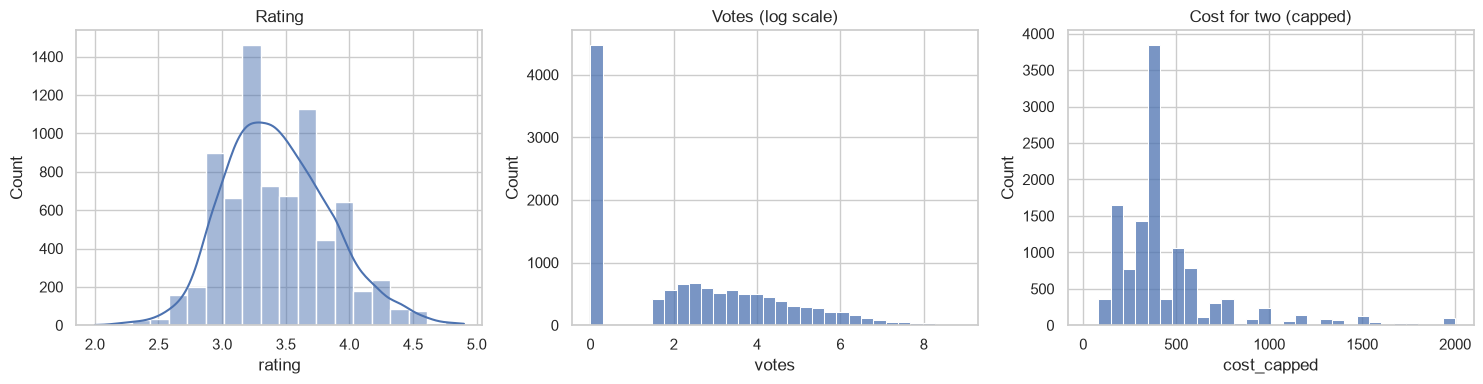

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rated["rating"], bins=20, kde=True, ax=ax[0]);            ax[0].set_title("Rating")
sns.histplot(np.log1p(df["votes"]), bins=30, ax=ax[1]);                ax[1].set_title("Votes (log scale)")
sns.histplot(df["cost_capped"], bins=30, ax=ax[2]);                    ax[2].set_title("Cost for two (capped)")
plt.tight_layout(); plt.show()

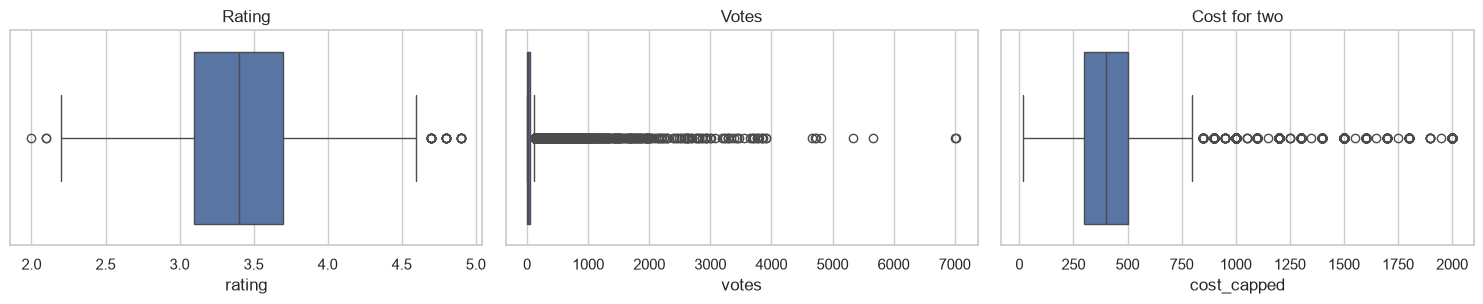

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
sns.boxplot(x=rated["rating"], ax=ax[0]);        ax[0].set_title("Rating")
sns.boxplot(x=df["votes"], ax=ax[1]);            ax[1].set_title("Votes")
sns.boxplot(x=df["cost_capped"], ax=ax[2]);      ax[2].set_title("Cost for two")
plt.tight_layout(); plt.show()

## 2. Who has no rating?

In [5]:
pd.crosstab(df["has_rating"], df["votes"] > 0, rownames=["has rating"], colnames=["has votes"])

has votes,False,True
has rating,,
False,4465,0
True,17,7652


Almost every unrated restaurant has zero votes, so "no rating" simply means "nobody has reviewed it yet". These rows are kept for locality counts but excluded from rating analysis and models.

## 3. Localities (grouping and aggregation)

Localities: 99 | with >= 40 rated restaurants: 58


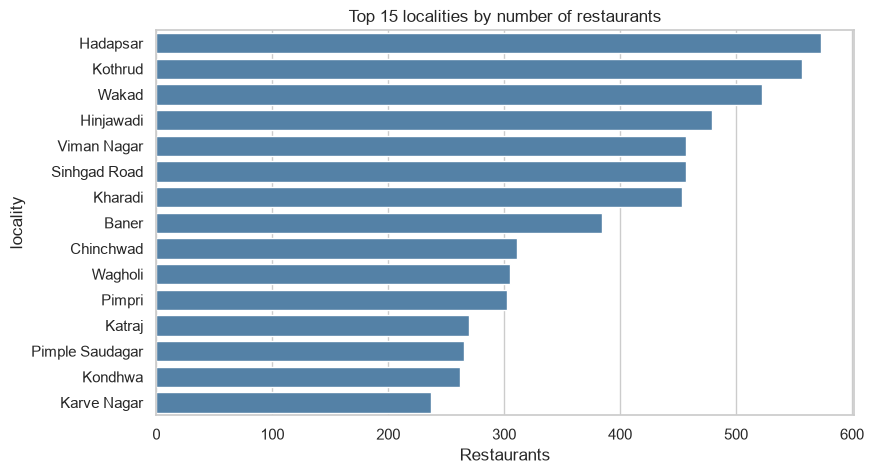

In [6]:
loc_counts = df["locality"].value_counts()
print("Localities:", len(loc_counts), "| with >= 40 rated restaurants:", (rated["locality"].value_counts() >= 40).sum())

plt.figure(figsize=(9, 5))
sns.barplot(x=loc_counts.head(15).values, y=loc_counts.head(15).index, color="steelblue")
plt.title("Top 15 localities by number of restaurants"); plt.xlabel("Restaurants"); plt.show()

In [7]:
# Aggregation per locality (only localities with >= 40 rated restaurants)
loc_pivot = (rated.groupby("locality")
                  .agg(rated_count=("rating", "count"),
                       avg_rating=("rating", "mean"),
                       median_cost=("cost_capped", "median"),
                       median_votes=("votes", "median")))
loc_pivot = loc_pivot[loc_pivot["rated_count"] >= 40].sort_values("avg_rating", ascending=False)
print(len(loc_pivot), "localities")
loc_pivot.head(8).round(2)

58 localities


,rated_count,avg_rating,median_cost,median_votes
locality,,,,
Koregaon Park,141,3.79,600.0,124.0
Kalyani Nagar,84,3.78,600.0,78.0
Bund Garden Road,43,3.76,1200.0,62.0
FC Road,65,3.74,500.0,171.0
Senapati Bapat Road,64,3.72,400.0,80.0
Deccan Gymkhana,46,3.65,500.0,66.0
JM Road,42,3.63,475.0,114.5
Baner,309,3.61,500.0,80.0


In [8]:
loc_pivot.tail(8).round(2)

,rated_count,avg_rating,median_cost,median_votes
locality,,,,
Pune-Solapur Road,49,3.25,500.0,15.0
Warje,52,3.25,450.0,14.0
Pimple Gurav,103,3.25,400.0,14.0
Wagholi,128,3.25,400.0,16.0
Lohegaon,80,3.21,400.0,12.0
Bhosari,105,3.16,500.0,13.0
Dhanori,48,3.16,400.0,16.0
Vishrantwadi,48,3.14,400.0,19.0


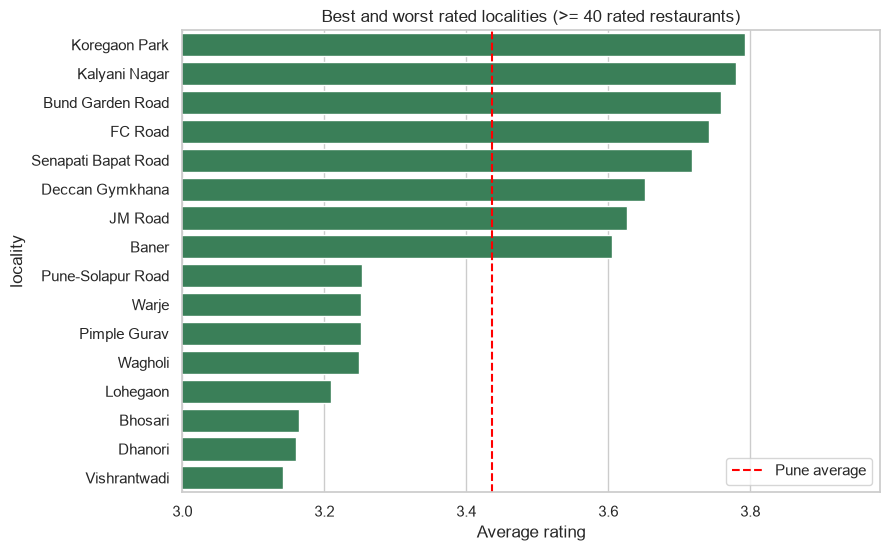

In [9]:
top_bottom = pd.concat([loc_pivot.head(8), loc_pivot.tail(8)])
plt.figure(figsize=(9, 6))
sns.barplot(x=top_bottom["avg_rating"], y=top_bottom.index, color="seagreen")
plt.axvline(rated["rating"].mean(), color="red", linestyle="--", label="Pune average")
plt.xlim(3, None); plt.legend(); plt.title("Best and worst rated localities (>= 40 rated restaurants)")
plt.xlabel("Average rating"); plt.show()

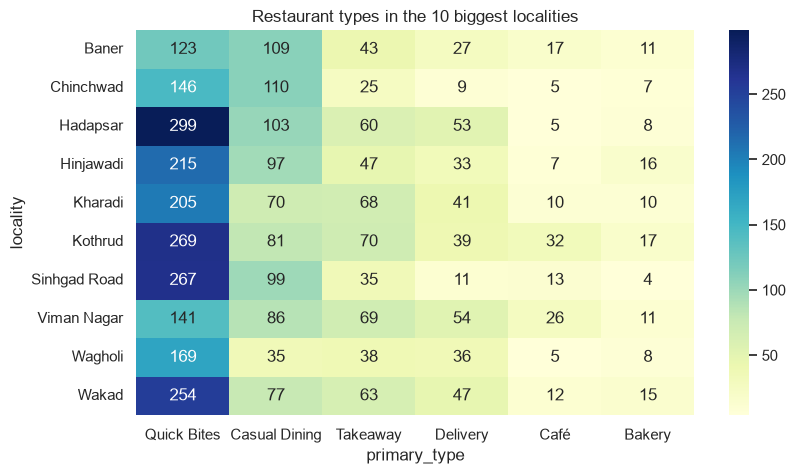

In [10]:
# Locality x restaurant type: how many of each type in the 10 biggest localities
top_loc = loc_counts.head(10).index
top_types = df["primary_type"].value_counts().head(6).index
ct = pd.crosstab(df[df["locality"].isin(top_loc)]["locality"],
                 df[df["locality"].isin(top_loc)]["primary_type"])[top_types]
plt.figure(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Restaurant types in the 10 biggest localities"); plt.show()

In [11]:
# A true pivot table: average rating for each locality (rows) x restaurant type (columns)
big_loc = loc_pivot.sort_values("rated_count", ascending=False).head(10).index
big_types = rated["primary_type"].value_counts().head(5).index
pt = pd.pivot_table(rated[rated["locality"].isin(big_loc) & rated["primary_type"].isin(big_types)],
                    index="locality", columns="primary_type", values="rating", aggfunc="mean")
pt.round(2)

primary_type,Café,Casual Dining,Delivery,Quick Bites,Takeaway
locality,,,,,
Baner,3.81,3.68,3.46,3.44,3.44
Hadapsar,3.50,3.29,3.38,3.28,3.16
Hinjawadi,3.48,3.55,3.47,3.34,3.40
Kharadi,3.66,3.59,3.51,3.36,3.55
Kothrud,3.74,3.51,3.27,3.40,3.32
Pimple Saudagar,3.48,3.40,3.48,3.39,3.33
Pimpri,3.46,3.40,3.12,3.33,3.34
Sinhgad Road,3.42,3.30,3.35,3.23,3.24
Viman Nagar,3.85,3.73,3.49,3.45,3.40


## 4. Restaurant type and cuisine

In [12]:
type_pivot = (rated.groupby("primary_type")
                   .agg(rated_count=("rating", "count"),
                        avg_rating=("rating", "mean"),
                        median_cost=("cost_capped", "median")))
type_pivot = type_pivot[type_pivot["rated_count"] >= 40].sort_values("avg_rating", ascending=False)
type_pivot.round(2)

,rated_count,avg_rating,median_cost
primary_type,,,
Bar,191,3.88,1500.0
Lounge,72,3.69,1500.0
Dessert Parlor,227,3.63,250.0
Café,307,3.62,450.0
Bakery,197,3.53,300.0
Food Truck,48,3.48,300.0
Casual Dining,2147,3.48,700.0
Beverage Shop,57,3.44,200.0
Sweet Shop,67,3.42,200.0


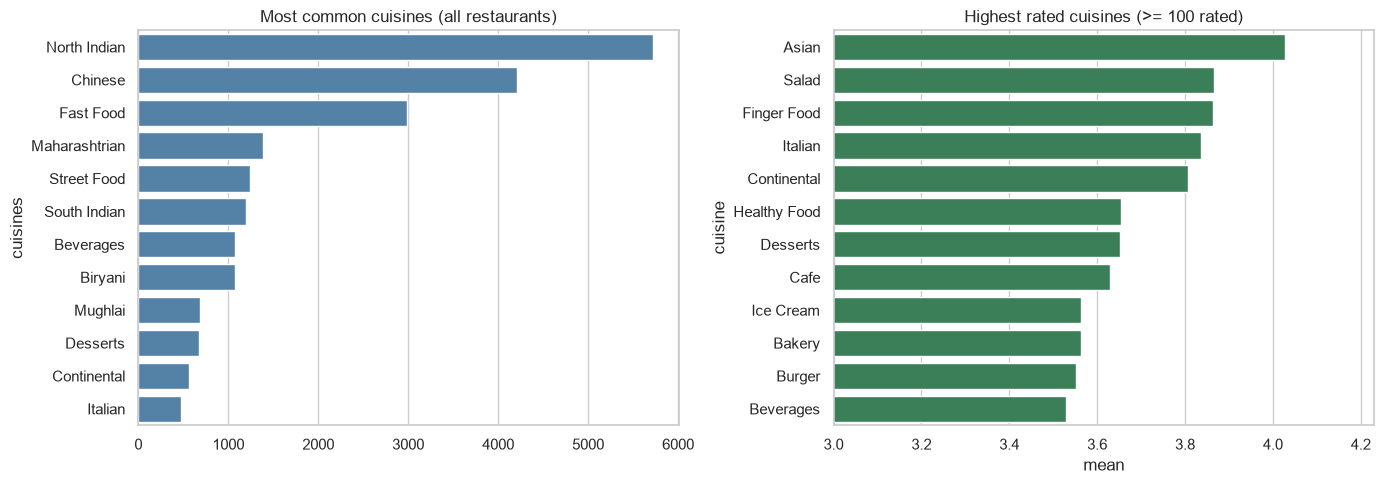

In [13]:
# One restaurant has several cuisines, so 'explode' the list into one row per cuisine
cuis = rated.assign(cuisine=rated["cuisines"].str.split("|")).explode("cuisine")
cuis_pivot = cuis.groupby("cuisine")["rating"].agg(["count", "mean"])
cuis_pivot = cuis_pivot[cuis_pivot["count"] >= 100].sort_values("mean", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=df["cuisines"].str.split("|").explode().value_counts().head(12).values,
            y=df["cuisines"].str.split("|").explode().value_counts().head(12).index, color="steelblue", ax=ax[0])
ax[0].set_title("Most common cuisines (all restaurants)")
sns.barplot(x=cuis_pivot["mean"].head(12), y=cuis_pivot.head(12).index, color="seagreen", ax=ax[1])
ax[1].set_xlim(3, None); ax[1].set_title("Highest rated cuisines (>= 100 rated)")
plt.tight_layout(); plt.show()

## 5. Price and rating

                 count  mean  median
price_band                          
(99.999, 300.0]   2217  3.37     3.3
(300.0, 400.0]    2135  3.36     3.3
(400.0, 450.0]     270  3.35     3.3
(450.0, 700.0]    1775  3.42     3.4
(700.0, 2000.0]   1272  3.72     3.8


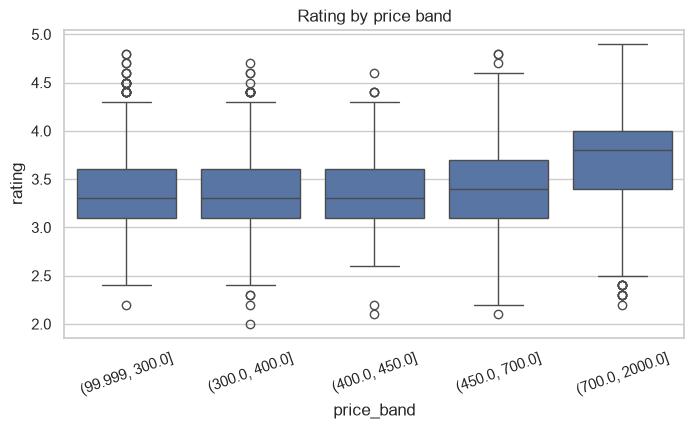

In [14]:
rated["price_band"] = pd.qcut(rated["cost_capped"], 5, duplicates="drop")
band = rated.groupby("price_band", observed=True)["rating"].agg(["count", "mean", "median"])
print(band.round(2))

plt.figure(figsize=(8, 4))
sns.boxplot(data=rated, x="price_band", y="rating")
plt.xticks(rotation=20); plt.title("Rating by price band"); plt.show()

## 6. Correlation and covariance

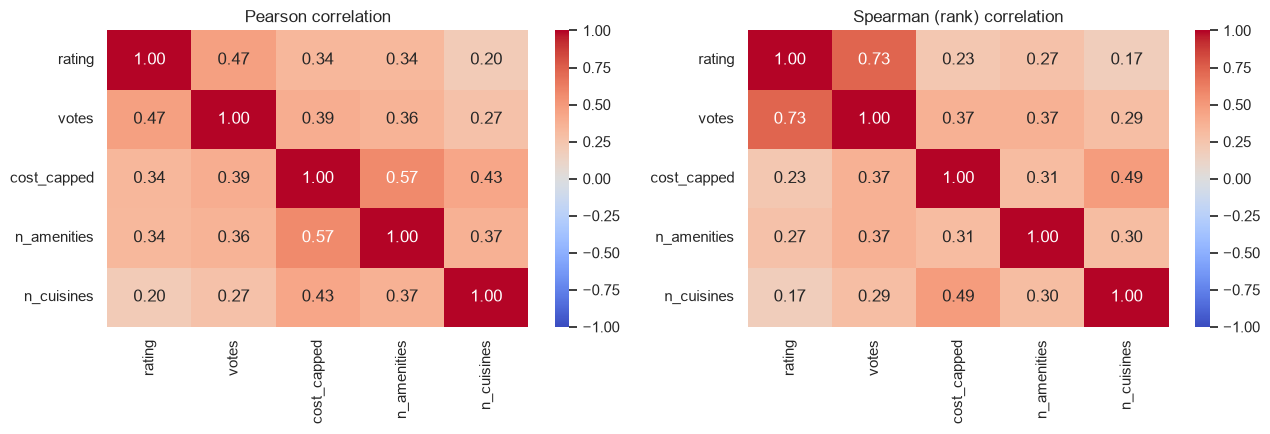

In [15]:
corr_cols = ["rating", "votes", "cost_capped", "n_amenities", "n_cuisines"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(rated[corr_cols].corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Pearson correlation")
sns.heatmap(rated[corr_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Spearman (rank) correlation")
plt.tight_layout(); plt.show()

In [ ]:
# Covariance depends on the units of each variable, so it is hard to compare across pairs.
# Correlation is covariance rescaled to the range -1..+1.
rated[corr_cols].cov().round(2)

**Why two correlations?** Pearson measures straight-line relationships and is distorted by the skewed `votes`. Spearman uses ranks, so it is more reliable for skewed data. Their gap for `rating` vs `votes` shows the relationship is strong but not a straight line.

## 7. Votes and rating reliability

         count  mean   std
votes                     
0-4        438  3.04  0.15
5-9       1230  3.10  0.14
10-24     1784  3.26  0.24
25-49     1205  3.43  0.32
50-99     1054  3.55  0.36
100-499   1444  3.76  0.40
500+       514  4.07  0.37


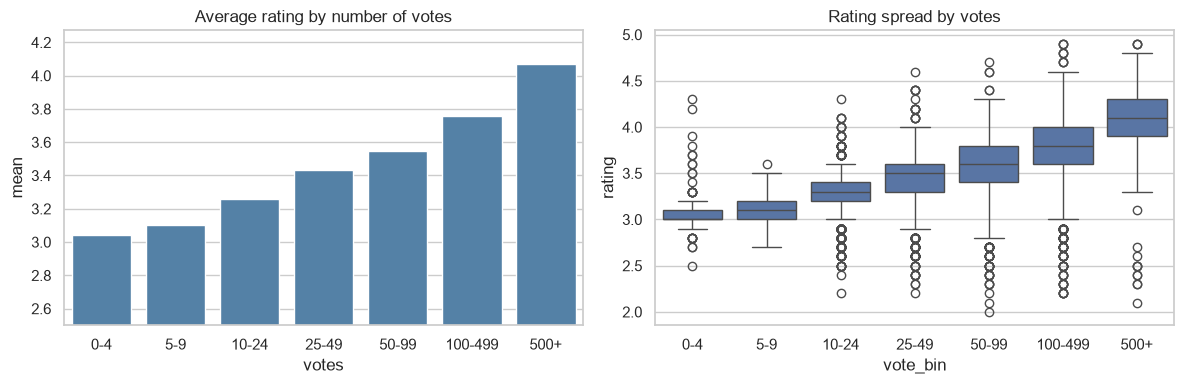

In [16]:
vote_bins = pd.cut(rated["votes"], [-1, 4, 9, 24, 49, 99, 499, 100000],
                   labels=["0-4", "5-9", "10-24", "25-49", "50-99", "100-499", "500+"])
vb = rated.groupby(vote_bins, observed=True)["rating"].agg(["count", "mean", "std"])
print(vb.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=vb.index.astype(str), y=vb["mean"], color="steelblue", ax=ax[0])
ax[0].set_title("Average rating by number of votes"); ax[0].set_ylim(2.5, None)
sns.boxplot(data=rated.assign(vote_bin=vote_bins), x="vote_bin", y="rating", ax=ax[1])
ax[1].set_title("Rating spread by votes")
plt.tight_layout(); plt.show()

Restaurants with very few votes cluster tightly around a low rating, while heavily reviewed ones rate much higher. This means **a rating is not equally trustworthy for every restaurant**, which is the motivation for our *Trust-adjusted Rating* in the Hidden Gems feature. It also warns us that `votes` is a very strong predictor, partly because popularity and rating move together.

## 8. Review patterns (star percentages)

In [17]:
star_cols = ["star5_pct", "star4_pct", "star3_pct", "star2_pct", "star1_pct"]
rated["rating_band"] = pd.cut(rated["rating"], [1.9, 3.0, 3.5, 4.0, 5.0],
                              labels=["<=3.0", "3.0-3.5", "3.5-4.0", ">4.0"])
mix = rated.groupby("rating_band", observed=True)[star_cols + ["polarization_pct"]].mean().round(1)
mix

,star5_pct,star4_pct,star3_pct,star2_pct,star1_pct,polarization_pct
rating_band,,,,,,
<=3.0,42.3,16.3,12.4,6.8,22.3,35.7
3.0-3.5,64.3,16.4,6.9,3.2,9.4,18.4
3.5-4.0,54.0,24.8,8.8,3.6,8.7,17.3
>4.0,58.4,27.0,6.6,2.8,5.2,10.5


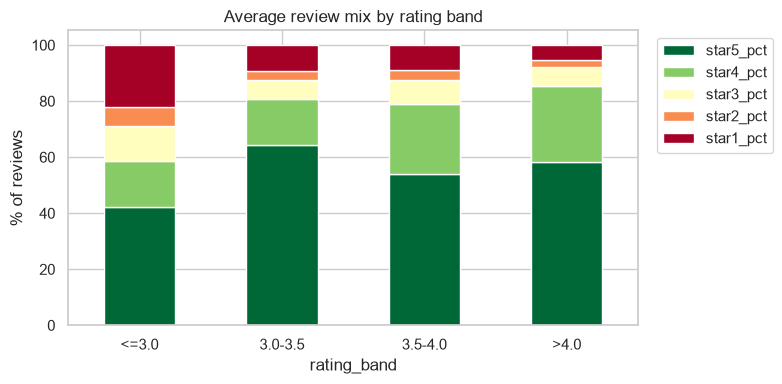

In [18]:
mix[star_cols].plot(kind="bar", stacked=True, figsize=(8, 4), colormap="RdYlGn_r")
plt.title("Average review mix by rating band"); plt.ylabel("% of reviews"); plt.xticks(rotation=0)
plt.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

In [19]:
# 'Love it or hate it' restaurants: many 5-star AND many 1-star reviews (needs enough votes to mean something)
polar = (rated[rated["votes"] >= 100]
         .sort_values("polarization_pct", ascending=False)
         [["name", "locality", "rating", "votes", "star5_pct", "star1_pct", "polarization_pct"]].head(10))
polar

,name,locality,rating,votes,star5_pct,star1_pct,polarization_pct
734,Mumbai Biryani House,Sinhgad Road,2.4,224,47.0,44.0,88.0
4799,King Punjab,Hadapsar,3.4,136,40.0,38.0,76.0
2958,New Burger Bits,Kondhwa,3.1,224,37.0,37.0,74.0
1549,Night Cravers,NIBM Road,3.4,307,46.0,36.0,72.0
11039,Night Byte At Hot Box,Wanowrie Kondhwa Area,2.7,158,39.0,35.0,70.0
11976,Night Riders,Magarpatta,3.1,379,35.0,36.0,70.0
423,Punjabi Chilly,Viman Nagar,4.1,123,43.0,35.0,70.0
3860,New Hyderabadi Biryani House,Magarpatta,3.6,492,36.0,34.0,68.0
3774,Megabites,"Magarpatta, Pune Sholapur Rd",2.9,101,34.0,43.0,68.0
11628,Question Mark - Taste of Assam,Hinjawadi,3.4,127,40.0,34.0,68.0


## 9. Which amenities go with higher ratings? (preview of Unit III tests)

This is a first look only. Whether a difference is *statistically significant* is decided by the t-tests in notebook 03.

In [20]:
rows = []
for a in amenity_cols:
    with_a = rated.loc[rated[a] == 1, "rating"]
    without = rated.loc[rated[a] == 0, "rating"]
    if len(with_a) >= 100 and len(without) >= 100:
        rows.append((a, len(with_a), with_a.mean(), without.mean(), with_a.mean() - without.mean()))
am = (pd.DataFrame(rows, columns=["amenity", "n_with", "mean_with", "mean_without", "difference"])
        .sort_values("difference", ascending=False))
am.head(8).round(2)

,amenity,n_with,mean_with,mean_without,difference
10,live_sports_screening,290,3.94,3.42,0.53
14,valet_parking_available,303,3.93,3.42,0.52
3,live_music,239,3.93,3.42,0.51
22,lgbtqia_friendly,161,3.93,3.43,0.50
17,nightlife,236,3.91,3.42,0.49
25,table_booking_recommended,563,3.85,3.40,0.45
18,kid_friendly,149,3.82,3.43,0.40
9,rooftop,106,3.80,3.43,0.37


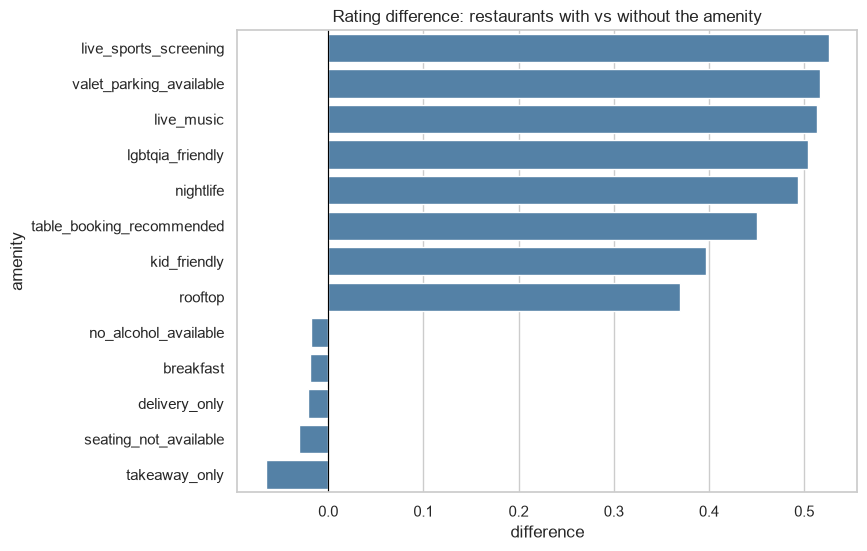

In [21]:
plt.figure(figsize=(8, 6))
pick = pd.concat([am.head(8), am.tail(5)])
sns.barplot(data=pick, x="difference", y="amenity", color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Rating difference: restaurants with vs without the amenity"); plt.show()

## 10. Key findings (check against your own outputs and put in the report)

1. **Skewed popularity:** half of all restaurants have fewer than ~10 votes while a few have thousands, so `votes` needs a log transform or ranks for modelling.
2. **Ratings sit in a narrow band:** the median is 3.4 and only about 11% of rated restaurants reach 4.0, so the "Highly Rated" class will be small.
3. **Votes and rating move together** (Spearman about 0.7): low-vote restaurants have unreliable, low ratings. This justifies a trust-adjusted rating.
4. **Locality matters:** Koregaon Park, Kalyani Nagar, FC Road and Bund Garden Road are at the top, while areas like Bhosari, Dhanori and Vishrantwadi are at the bottom (among localities with at least 40 rated restaurants).
5. **Type and price matter:** bars, lounges, dessert parlours and cafes beat quick-bite and takeaway places, and the most expensive price band stands out.
6. **Amenities that signal premium service** (live sports screening, valet parking, live music, table booking recommended) show clearly higher average ratings.
7. **Correlation is not causation:** a bar having a higher rating does not mean adding a bar raises a restaurant's rating.

**Next:** `03_statistics.ipynb` (t-test, ANOVA, chi-square).